# Experiment Claims

**Source file:** `benchmark_results.pkl`

---

## Claim 3 (Training Bounds): Redundancy follows a 1/m decay.

A fresh transformer is trained per value of m in {10, 25, 50, 75, 100, 150, 200, 300, 500, 1000, 5000, 10000} on the source p=0.3. Redundancy is measured as average BPS minus H(0.3). The log-log slope over m in {50..500} fits to -1.19, close to the -1 theoretical prediction. This is the primary empirical validation of the scaling bound that Høst-Madsen builds on.

*Key numbers:* m=50 redundancy 0.0400, m=500 redundancy 0.0028. Slope ≈ -1.19.

---

## Claim 4 (Training Bounds): The transformer crosses below Laplace at m ≈ 100.

Laplace redundancy is flat at 0.0220. The transformer drops below at m=100 (0.0211) and is clearly dominant by m=150 (0.0116). Around 100 training sequences is the concrete crossover point. Beyond m≈1000 the curve floors at the test-set noise level and further training has no measurable effect.

*Key numbers:* Crossover between m=100 and m=150. Floor visible at m=1000 (0.0060), negative values at m=5000 (-0.0032).


In [37]:
import sys
sys.path.append('../../')

from mingpt.model import GPT
from mingpt.trainer import Trainer
import torch
from torch.utils.data import Dataset
import numpy as np
import torch
import torch.nn.functional as F
from mingpt.model import GPT
import pickle
import matplotlib.pyplot as plt

# Model functions

In [38]:
class ModelDataset(Dataset):
    def __init__(self, p, n=10, num_samples=10000):
        self.n = n
        self.block_size = n - 1
        # pre-generate all sequences at init
        self.data = []
        for _ in range(num_samples):
            seq = torch.bernoulli(torch.full((n,), p)).long()
            x = seq[:-1].clone()
            y = seq[1:].clone()
            self.data.append((x, y))

    def get_block_size(self):
        return self.block_size

    def __getitem__(self, idx):
        return self.data[idx]  # returns fixed pre-generated sequence

    def __len__(self):
        return len(self.data)

In [39]:
# Model configure

def model_configure(dataset, iters=1000, learn_rate=1e-4):
    model_config = GPT.get_default_config()
    model_config.model_type = 'gpt-nano'
    model_config.vocab_size = 2
    model_config.block_size = dataset.get_block_size()
    model = GPT(model_config)

    device = 'mps'
    model = model.to(device)

    train_config = Trainer.get_default_config()
    train_config.learning_rate = learn_rate
    train_config.max_iters = iters
    train_config.num_workers = 0
    train_config.device = 'mps'
    trainer = Trainer(train_config, model, dataset)
    return model, trainer

def batch_end_callback(trainer):
    if trainer.iter_num % 100 == 0:
        print(f"iter_dt {trainer.iter_num}; iter {trainer.iter_num}: train loss {trainer.loss.item():.5f}")

def train_run(model, trainer, output_name):
    save_dir = model_save_folder + output_name
    print(f'Saving to {save_dir}')
    trainer.set_callback('on_batch_end', batch_end_callback)
    trainer.run()
    torch.save({
        'state_dict': model.state_dict(),
        'block_size': model.block_size
    }, save_dir)
    print(f'Saved to {save_dir}')

# Experiment infrastructure

In [40]:
experiment_save_folder = './experiments/'
N_values = [10, 25, 50, 100, 200, 499]

In [41]:

def iid_generate(p_dict, N):
    p0 = p_dict[0]
    p1 = p_dict[1]
    return np.random.choice([0,1], size=N, p=[p0, p1])

def generate_bin_pmf():
    p = np.random.rand()
    dict_out = {
        0: p,
        1: 1-p
    }
    return dict_out

def convert_sample_to_pmf(sample):
    values, counts = np.unique(sample, return_counts=True)
    probs = counts/counts.sum()
    return dict(zip(values, probs))

def entropy_calc(pmf):
    pmf = clean_pmf(pmf)
    pmf_array = np.asarray(list(pmf.values()))
    return -np.sum(pmf_array * np.log2(pmf_array))

def clean_pmf(pmf):
    return {k: v for k, v in pmf.items() if v > 0.0}

In [42]:
def sequential_universal_source_coding(seq, p_array = None):
    total_bits = 0
    k = 0
    i = 0

    for bit in seq:
        if p_array is not None:
            p1 = p_array[i]
        else:
            p1 = (k+1) / (i+2)
        p0 = 1-p1

        if bit == 1:
            total_bits += -np.log2(p1)
        else:
            total_bits += -np.log2(p0)
        k += bit
        i += 1

    bits_per_symbol = total_bits / len(seq)
    return bits_per_symbol

In [43]:

# generate an array of probabilities given a bit sequence

def transformer_p_array(sequence, model, device='mps'):
    model.eval()
    sequence=torch.tensor(sequence, dtype=torch.long, device=device).unsqueeze(0)

    with torch.no_grad():
        logits, _ = model(sequence)  # [1, T, vocab_size]
        # convert to probabilities
        probs = F.softmax(logits, dim=-1)  # [1, T, vocab_size]
        # extract probability of token=1 at each timestep
        p_array = [0.5] + probs[0, :-1, 1].tolist()
    
    return p_array

In [44]:
def load_model(model_dir):
    checkpoint = torch.load(model_dir, map_location='cpu')
    block_size = checkpoint['block_size']
    
    model_config = GPT.get_default_config()
    model_config.model_type = 'gpt-nano'
    model_config.vocab_size = 2
    model_config.block_size = block_size
    
    model = GPT(model_config)
    model.load_state_dict(checkpoint['state_dict'])
    model = model.to('mps')
    model.eval()
    return model

In [45]:
# Transformer vs Laplace prior quality at small N

def run_experiment(model, p_values, N_values, output_file, n_trials=100, device='mps'):
    """
    For each (p, N) pair, run n_trials with identical sequences for both methods.
    Returns nested dict: results[p][N] = {'laplace': (mean, std), 'transformer': (mean, std)}
    """
    all_results = {}
    save_dir = experiment_save_folder + output_file
    print(f'Saving to {save_dir}')

    for p_true in p_values:
        print(f"\nRunning p={p_true}")
        p_dict = {0: 1 - p_true, 1: p_true}
        all_results[p_true] = {}

        for N in N_values:
            laplace_bps_trials = []
            transformer_bps_trials = []

            for trial in range(n_trials):
                # Same sequence for both methods
                seq = iid_generate(p_dict, N)

                # Laplace
                bps_lap = sequential_universal_source_coding(seq)
                laplace_bps_trials.append(bps_lap)

                # Transformer
                p_array = transformer_p_array(seq, model, device=device)
                bps_trans = sequential_universal_source_coding(seq, p_array=p_array)
                transformer_bps_trials.append(bps_trans)

            all_results[p_true][N] = {
                'laplace': (np.mean(laplace_bps_trials), np.std(laplace_bps_trials)),
                'transformer': (np.mean(transformer_bps_trials), np.std(transformer_bps_trials)),
                'entropy': entropy_calc({p_true: p_true, 1-p_true: 1-p_true})
            }
            print(f"  N={N}: laplace={np.mean(laplace_bps_trials):.4f}, transformer={np.mean(transformer_bps_trials):.4f}")

    with open(save_dir, 'wb') as f:
        pickle.dump(all_results, f)

    print(f'Saved experiment to {save_dir}')




In [46]:
import os, pickle

num_samples_sweep = [10, 25, 50, 75, 100, 150, 200, 300, 500, 1000, 5000, 10000]
seq_samples  = 500
iters        = 500
learn_rate   = 1e-4
p_true       = 0.3
N            = 100
n_trials     = 500
BENCH_PKL    = './experiments/benchmark_results.pkl'

entropy = entropy_calc({p_true: p_true, 1-p_true: 1-p_true})

if os.path.exists(BENCH_PKL):
    print(f'Benchmark results found, loading {BENCH_PKL}')
    with open(BENCH_PKL, 'rb') as f:
        saved = pickle.load(f)
    benchmark_results = saved['transformer']
    laplace_redundancy = saved['laplace']
else:
    laplace_bps_trials = []
    for _ in range(n_trials):
        seq = iid_generate({0: 1-p_true, 1: p_true}, N)
        laplace_bps_trials.append(sequential_universal_source_coding(seq))
    laplace_redundancy = float(np.mean(laplace_bps_trials)) - entropy

    benchmark_results = {}
    for num_samples in num_samples_sweep:
        model_path = model_save_folder + f'benchmark_{num_samples}.pt'
        if os.path.exists(model_path):
            print(f'Checkpoint found, loading benchmark_{num_samples}.pt')
            model = load_model(model_path)
        else:
            dataset = ModelDataset(p=p_true, n=seq_samples, num_samples=num_samples)
            model, trainer = model_configure(dataset, iters=iters, learn_rate=learn_rate)
            train_run(model, trainer, f'benchmark_{num_samples}.pt')

        bps_trials = []
        for _ in range(n_trials):
            seq = iid_generate({0: 1-p_true, 1: p_true}, N)
            p_array = transformer_p_array(seq, model)
            bps_trials.append(sequential_universal_source_coding(seq, p_array=p_array))
        benchmark_results[num_samples] = float(np.mean(bps_trials)) - entropy
        print(f"num_samples={num_samples}: redundancy={benchmark_results[num_samples]:.4f}  laplace={laplace_redundancy:.4f}")

    with open(BENCH_PKL, 'wb') as f:
        pickle.dump({'transformer': benchmark_results, 'laplace': laplace_redundancy}, f)
    print(f'Saved {BENCH_PKL}')

print(f'\nLaplace redundancy: {laplace_redundancy:.4f}')
print(f'Benchmark results: {benchmark_results}')


Benchmark results found, loading ./experiments/benchmark_results.pkl

Laplace redundancy: 0.0220
Benchmark results: {10: np.float64(0.37308369947952036), 25: np.float64(0.11416231901237084), 50: np.float64(0.04001359472062238), 75: np.float64(0.024810723683697078), 100: np.float64(0.02107552420204606), 150: np.float64(0.011615497057385071), 200: np.float64(0.00813046526547645), 300: np.float64(0.004456414104141215), 500: np.float64(0.002836710948187715), 1000: np.float64(0.005993868287943571), 5000: np.float64(-0.0031694961930797128), 10000: np.float64(-0.001882683676919794)}


In [47]:
with open('./experiments/benchmark_results.pkl', 'rb') as f:
    data = pickle.load(f)


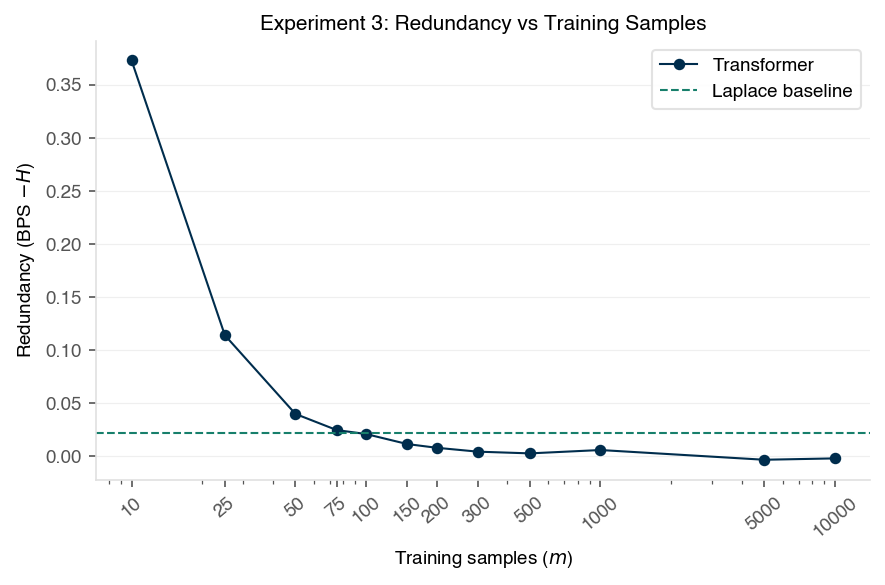

Saved figures/redundancy_vs_training


In [48]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Style ──────────────────────────────────────────────────────────────────
C_TRANSFORMER = '#002d4d'
C_LAPLACE     = '#177F6B'
C_CTW         = '#9C4732'
C_ENTROPY     = '#888888'
BG            = '#FFFFFF'
GRID          = '#E0E0E0'

matplotlib.rcParams.update({
    'font.family':       'sans-serif',
    'font.sans-serif':   ['Helvetica', 'Arial', 'DejaVu Sans'],
    'axes.facecolor':    BG,
    'figure.facecolor':  BG,
    'axes.edgecolor':    GRID,
    'axes.linewidth':    0.8,
    'grid.color':        GRID,
    'grid.linewidth':    0.6,
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'axes.labelsize':    10,
    'axes.titlesize':    10,
    'axes.titleweight':  'bold',
    'legend.fontsize':   9,
    'legend.framealpha': 0.92,
    'legend.edgecolor':  GRID,
    'lines.linewidth':   1.0,
    'lines.markersize':  4.5,
})

def style_ax(ax):
    ax.grid(True, axis='y', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

def set_log_xticks(ax, N_values):
    ax.set_xscale('log')
    ax.set_xticks(N_values)
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis='x', rotation=40)

import pickle, os
os.makedirs('figures', exist_ok=True)

with open('./experiments/benchmark_results.pkl', 'rb') as f:
    data = pickle.load(f)

n_vals       = list(data['transformer'].keys())
redundancies = list(data['transformer'].values())
laplace_val  = data['laplace']

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
fig.patch.set_facecolor(BG)

ax.plot(n_vals, redundancies, color=C_TRANSFORMER, lw=1.0, ls='-',
        marker='o', ms=4.5, label='Transformer')
ax.axhline(y=laplace_val, color=C_LAPLACE, lw=1.0, ls='--',
           label='Laplace baseline')

set_log_xticks(ax, n_vals)
ax.set_xlabel('Training samples ($m$)', fontsize=9)
ax.set_ylabel('Redundancy (BPS $- H$)', fontsize=9)
ax.set_title('Experiment 3: Redundancy vs Training Samples', pad=5)
ax.legend()
style_ax(ax)
plt.tight_layout()
plt.savefig('figures/redundancy_vs_training.pdf', bbox_inches='tight', dpi=150)
plt.savefig('figures/redundancy_vs_training.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/redundancy_vs_training')
